# Probability Distributions II
# Continuous Distributions, Family I

This article is part of a series:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20I%20-%20Discrete%20Distributions.ipynb">Probability Distributions I - Discrete Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20II%20-%20Continuous%20Distributions%20I.ipynb">Probability Distributions II - Continuous Distributions I</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Continuous%20Distributions%20II.ipynb">Probability Distributions III - Continuous Distributions II</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20IV%20-%20Gaussian%20Processes.ipynb">Probability Distributions IV - Gaussian Processes</a>

# Outline
- Beta
- Dirichlet
- Uniform
- Von Mises
- Normal
- Half-Normal
- Multivariate Normal
- Log-Normal
- Student's T
- Half Student's-T
- Cauchy
- Half Cauchy

<img src="https://github.com/pw598/Articles/blob/main/img/continuous_dists_I.png?raw=true" style="height: 400px; width: auto;">

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import arviz as az
plt.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (6,4)

# Beta

The Beta distribution is a continuous distribution often dubbed the probability distribution of probabilities, as it is a continuous distribution on the interval $(0,1)$. It can be used to infer the probability of an event when we have information about the volumes of successes and failures.

<u><i>PDF, Parameterization 1:</i></u>

$f(y; \alpha, \beta) = \frac{ \Gamma(\alpha + \beta) }{ \Gamma(\alpha) \Gamma(\beta) } y^{\alpha-1} (1-y)^{\beta-1}, ~~y \in (0,1)$

$\Gamma$ is the Gamma function,

- $\Gamma(a) = \int_0^{\infty} x^{\alpha} e^{-y} \frac{dy}{y}, \alpha \gt 0$

- $\Gamma(n) = (n-1)!$ if $n$ is a positive integer.

</br>
<u><i>PDF, Parameterization 2:</i></u>

$f(y; \alpha, \beta) = \frac{y^{\alpha-1}(1-y)^{\beta-1}}{B(\alpha, \beta)},$

where $B(\alpha, \beta)$ is the Beta function,

$B(x, y) = \frac{\Gamma(x)\Gamma(y)}{\Gamma(x + y)}$

</br>
<u><i>Expected Value:</i></u> $\mu = \frac{\alpha}{\alpha + \beta}$</u>

<u><i>Variance:</i></u> $\frac{ \mu(1-\mu) }{ \alpha + \beta+1 }$</u>

<u><i>Shapes:</i></u>

By varying the values of $\alpha$ and $\beta$, the PDF takes on different shapes.<sup>[1]</sup>

- If $\alpha \lt 1$and $ \lt 1$, the PDF is U-shaped and opens upward
- If $\alpha \gt 1$and $ \gt 1$, the PDF opens downward
- If $\alpha = \beta$, the PDF is symmetric about $0.5$
- If $\alpha \gt \beta$, the PDF favors values lower than $0.5$
- If $\alpha \lt \beta$, the PDF favors values greater than $0.5$

# Dirichlet

The Dirichlet is a multivariate generalization of the Beta, where instead of describing the probability of one of two outcomes (a Bernoulli trial), it describes the probability of $K$ outcomes. The Beta distribution arises when $K=2$.

<u><i>PDF:</i></u>

$f(\boldsymbol{\theta};\boldsymbol{\alpha}) = \frac{1}{B(\boldsymbol{\alpha})}\,\prod_{i=1}^K \theta_i^{\alpha_i-1},$

<u><i>Expected Value:</i></u> $\left<\theta_i\right> = \displaystyle{\frac{\alpha_i}{\sum_{i=k}^K \alpha_k}}$

<u><i>Variance:</i></u> $\displaystyle{\frac{\left<\theta_i\right>(1-\left<\theta_i\right>)}{1 + \sum_{k=1}^K \alpha_k}}$

# Uniform

The Uniform distribution is a special case of the Beta, in that $\text{Beta}(1,1) = \text{Unif}(0,1)$. For a Uniform distribution, the probability of a draw from any interval within the interval is proportional to the length of the interval. It theoretically takes on a constant value, however sampling variability does occur.

<u><i>PMF:</i></u>

$f(y;\alpha, \beta) = \left\{\begin{array}{ccl}\displaystyle{\frac{1}{\beta-\alpha}}&&\alpha\le y\le\beta\\[0.5em] 0 && \text{otherwise}\end{array}\right.$

<u><i>Expected Value:</i></u> $\displaystyle{\frac{\alpha + \beta}{2}}$

<u><i>Variance:</i></u> $\displaystyle{\frac{(\beta - \alpha)^2}{12}}$

<u><i>CDF:</i></u>

$F(y; \alpha, \beta) = \left\{\begin{array}{ccl} 0 && y < a \\[0.5em]\displaystyle{\frac{y-\alpha}{\beta-\alpha}}&&\alpha\le y\le\beta\\[0.5em] 1 && y > \beta\end{array}\right.$

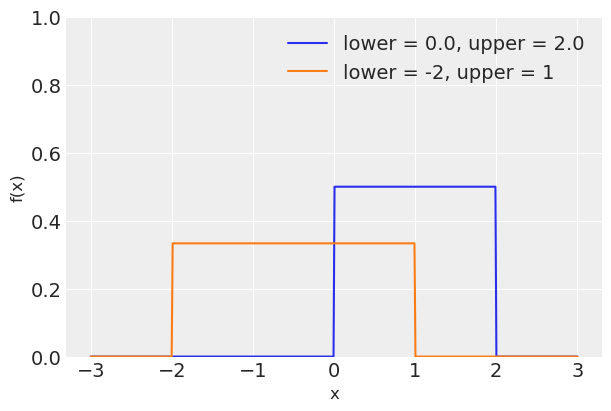

In [3]:
x = np.linspace(-3, 3, 500)
ls = [0., -2]
us = [2., 1]
for l, u in zip(ls, us):
    y = np.zeros(500)
    y[(x<u) & (x>l)] = 1.0/(u-l)
    plt.plot(x, y, label='lower = {}, upper = {}'.format(l, u))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 1)
plt.legend(loc=1)
plt.show()

# Von Mises

The Von Mises distribution is unique in that its random variable is periodic in nature. It can be thought of as an approximation to the Normal distribution that lives on a circular domain. One example application is to model the angular position of an object that moves in a circle; another is toward time-periods (day of week, hour of day, etc.), since periodic. When $\kappa$ is very large, it approximates a Normal distribution, and when $\kappa$ is very small, it approximates a Uniform distribution.

The location parameter $\mu$ determines the location of its peak, and the strictly positive shape parameter $\kappa$ determines the width of the peak. Because the Von Mises is defined in a periodic domain, it's random variable must be restricted to live on an interval of length $2 \pi$, such as $[0, 2 \pi)$ or $[-\pi, \pi)$.

<u><i>PDF:</i></u>

$f(y;\mu, \kappa) = \frac{\mathrm{e}^{-\kappa\cos(y-\mu)}}{2\pi I_0(\kappa)}$

where I_0 is the modified Bessel function,

$I_\alpha(x) = \frac{1}{\pi}\int_0^\pi\,\mathrm{d}\theta\,\cos(\alpha\theta)\,\mathrm{e}^{x\cos\theta},$

<u><i>Expected Value:</i></u> $\mu$

<u><i>Variance:</i></u> $\displaystyle{1 - \frac{I_1(\kappa)}{I_0(\kappa)}}$

<u><i>CDF:</i></u>

$F(y;\mu, \kappa) = \int_{-\pi}^y\mathrm{d}x\,f(x;\mu,\kappa) = \frac{1}{2\pi I_0(\kappa)}\,\int_{-\pi}^y\mathrm{d}x\,\mathrm{e}^{-\kappa\cos(y-\mu)}$

<u><i>Conjugate Prior:</i></u>

The conjugate prior for the Von Mises is itself a Von Mises distribution

- Conjugate Prior: $p(\mu|\mu_0, \kappa_0) = \frac{1}{2 \pi I_0 (\kappa_0)} e^{\kappa_0 ~cos(\mu - \mu_0)}$

- Likelihood: $f(\theta|\mu, \kappa) = \prod_{i=1}^n \frac{1}{ 2 \pi I_0(\kappa) } e^{\kappa ~cos(\theta_i - \mu)}$

for a set of observations $:\theta_1, \theta_2, \ldots, \theta_n$:

- Posterior: $p(\mu|\theta) = \frac{1}{ 2 \pi I_0 (\kappa_{post}) } e^{\kappa_{post} ~cos(\mu - \mu_{post})}$

with

- $\mu_{post} = atan2( \kappa ~sin(\bar{\theta}) + \kappa_0 ~sin(\mu_0), \kappa ~cos (\bar{\theta}) + \kappa_0 ~cos(\mu_0) )$

- $k_{post} = \sqrt{ \kappa ~cos(\bar(\theta) + \kappa_0 ~cos(\mu_0))^2 + (\kappa ~sin(\bar{\theta}) + \kappa ~sin(\mu_0))^2 }$

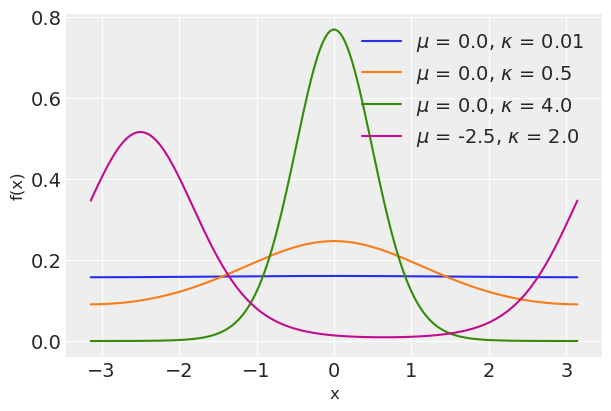

In [4]:
x = np.linspace(-np.pi, np.pi, 200)
mus = [0., 0., 0.,  -2.5]
kappas = [.01, 0.5,  4., 2.]
for mu, kappa in zip(mus, kappas):
    pdf = st.vonmises.pdf(x, kappa, loc=mu)
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\kappa$ = {}'.format(mu, kappa))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Normal

The Normal distribution is a symmetric distribution, in which the mean, median, and mode are equal. It maximizes entropy given a fixed mean and variance, and represents the accumulation of additive errors/processes. If errors or random effects are additive and independent, the central limit theorem (CLT) ensures the resulting aggregate distribution will be approximately Normal for large but finite sums. A Normal distribution with mean $0$ and variance $1$ is known as the standard Normal distribution.

The log of the normal distribution is a parabola-shaped function of y centered at $\mu$, which highlights how deviations from the mean are penalized quadratically. $\pi$ appears in the PDF because the integral of the function $e^{-x^2}$ is knkown to be $\sqrt{\pi}$, but for a more complete and visual explanation, see <a href="https://www.3blue1brown.com/lessons/gaussian-integral">this video</a> from 3Blue1Brown.

Sometimes (such as with conjugate-prior relationships), instead of speaking of or parameterizing things in terms of variance $\sigma^2$, we use precision $\tau = \frac{1}{\sigma^2}$.

<u><i>Relationships:</i></u>

CLT aside, there are several distributions which mathematically approach the Normal under certain conditions.

- Beta: when parameters $\alpha$ and $\beta$ are both large (i.e., $\gt 1$), the Beta approaches a Normal with mean $\frac{\alpha}{\alpha+\beta}$ and variance $\frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$.

- Binomial: when $n$ is large and $p$ is neither close to $0$ nor $1$, the Binomial approximates a Normal with mean $np$ and variance $np(1-p)$.

- Poisson: when $\lambda$ is large, the Poisson can be approximated by a Normal distribution with mean $\lambda$ and variance $\lambda$.

- Student-T: when the degrees of freedom $\nu$ is large, the standard t-distribution approximates a standard Normal with mean $0$ and variance $1$.

<u><i>PDF:</i></u>

$f(y;\mu, \sigma) = \sqrt{\frac{2}{\pi\sigma^2}}\,\mathrm{e}^{-(y-\mu)^2/2\sigma^2}.$

<u><i>Expected Value:</i></u> $\mu$

<u><i>Variance:</i></u> $\sigma^2$

<u><i>CDF:</i></u>

$F(y;\mu, \sigma) = \left\{\begin{array}{cll}
\displaystyle{\text{erf}\left(\frac{y - \mu}{\sigma\sqrt{2}}\right)} & & y \ge \mu,\\[0.5em]
0 & & \text{otherwise},
\end{array}
\right.$

where $\text{erf}$ is the error function,

$\text{erf}(x) = \frac{2}{\sqrt{\pi}}\int_0^x dt\,e^{-t^2}$

<u><i>Conjugate Prior - Known Variance:</i></u>

Conjugate Prior: $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$

Likelihood: $Y \sim \displaystyle \prod_{i=1}^n \frac{1}{2 \pi \sigma^2} ~exp \left( - \frac{(x_i - \mu)^2}{2 \sigma^2} \right)$

Posterior: $P(\mu, \sigma; Y) \sim \mathcal{N}(\mu_{post}, \tau^2_{post}$

where 

- $\mu_{post} = \frac{ \tau_0^2 \sum_{i=1}^n x_i + \sigma^2 \mu_0 }{ n \sigma^2 + \tau_0^2 }$

- $\tau_{post} = \frac{ \sigma^2 \tau_0^2 }{ n \sigma^2 + \tau_0^2 }$

- $mu_0$ is the prior mean

- $\tau_0^2$ is the prior variance of $\mu$


<u><i>Conjugate Prior - Unknown Variance:</i></u>

Conjugate Prior: $\mu \sim \mathcal{N}(\mu_0, \tau_0^2), and \sigma^2 \sim InvGamma(\alpha_0, beta_0)$

- $\alpha_0$ is the shape parameter

- $\beta_0$ is the scale parameter

Likelihood: $P(y; \mu, \sigma) = \displaystyle \prod_{i=1}^n \frac{1}{2 \pi \sigma^2} ~exp \left( - \frac{(x_i - \mu)^2}{2 \sigma^2} \right)$

Posterior for $\mu$: 

$P(\mu; Y) \sim \mathcal{N}(\mu_{post}, \sigma_{post}^2$

where

- $\mu_{post} = \frac{ \tau_0^2 \sum_{i=1}^n x_i + \sigma^2 \mu_0 }{ n \sigma^2 + \tau_0^2 }$

- $\sigma^2 = \frac{ \sigma^2 \tau_0^2 }{ n \sigma^2 + \tau_0^2 }$

Posterior for $\sigma^2$:

$P(\sigma; Y) \sim InvGamma \left( \alpha_0 + \frac{n}{2}, \beta + \frac{1}{2} \displaystyle \sum_{i=1}^n (x_i - \bar{x})^2 \right)$

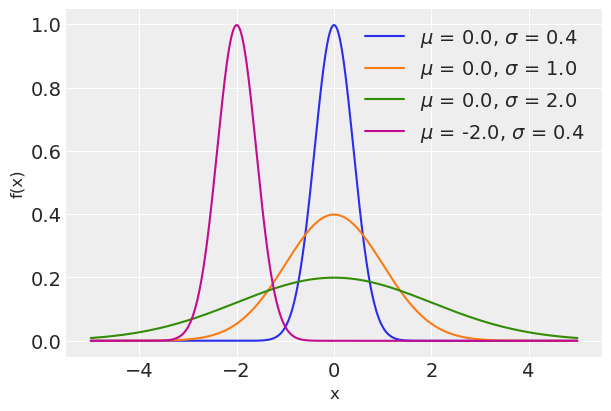

In [5]:
x = np.linspace(-5, 5, 1000)
mus = [0., 0., 0., -2.]
sigmas = [0.4, 1., 2., 0.4]
for mu, sigma in zip(mus, sigmas):
    pdf = st.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}'.format(mu, sigma))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Half-Normal

The Half-Normal distribution is a truncated and re-normalized version of the Normal which does not include values below $\mu$ (which is no longer the mean). This is convenient when only wanting to see outcomes in the positive domain (perhaps with a mean of 0).

<u><i>PDF:</i></u>

$f(y;\mu, \sigma) = \sqrt{\frac{2}{\pi\sigma^2}}\,\mathrm{e}^{-(y-\mu)^2/2\sigma^2}.$

<u><i>Expected Value:</i></u> $\displaystyle{\mu + \sqrt{\frac{2\sigma^2}{\pi}}}$

<u><i>Variance:</i></u> $\displaystyle{\left(1 - \frac{2}{\pi}\right)\sigma^2}$

<u><i>CDF:</i></u>

$F(y;\mu, \sigma) = \left\{\begin{array}{cll}
\displaystyle{\text{erf}\left(\frac{y - \mu}{\sigma\sqrt{2}}\right)} & & y \ge \mu,\\[0.5em]
0 & & \text{otherwise},
\end{array}
\right.$

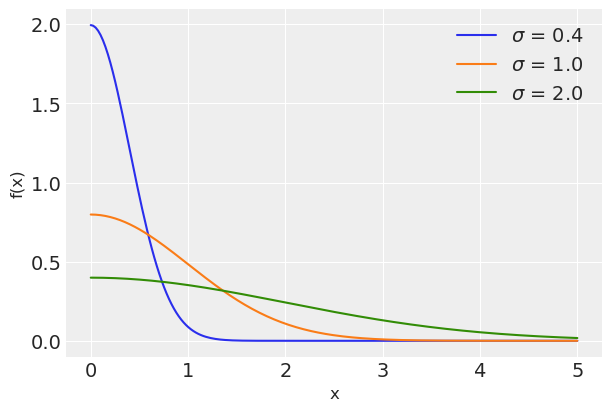

In [7]:
x = np.linspace(0, 5, 200)
for sigma in [0.4, 1., 2.]:
    pdf = st.halfnorm.pdf(x, scale=sigma)
    plt.plot(x, pdf, label=r'$\sigma$ = {}'.format(sigma))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Multivariate Normal

The Multivariate Normal (MVN) distribution is a generalization of the Normal to higher dimensions. The marginals of an MVN are themselves normally distributed. It is parameterized by a mean vector $\mathbf{\mu}$ and covariance matrix $\mathbf{\Sigma}$. If $\mathbf{\Sigma} = \sigma^2 \mathbf{I}$, then the distribution is spherically symmetric.

<u><i>PDF:</i></u>

$f(\mathbf{y};\boldsymbol{\mu}, \mathsf{\Sigma}) = \frac{1}{\sqrt{(2\pi)^K \mathrm{det}\mathsf{\Sigma}}}\,\exp\left[-\frac{1}{2}(\mathbf{y} - \boldsymbol{\mu})^\mathsf{T} \cdot \mathsf{\Sigma}^{-1} \cdot (\mathbf{y} - \boldsymbol{\mu})\right].$

<u><i>Expected Value:</i></u> $E[y_i] = \mu_i$

<u><i>Variance:</i></u> $Var[y_i] = \Sigma_{ii}$

<u><i>Covariance:</i></u> $Cov[y_i, y_j] = \Sigma_{ij}$

<u><i>Conjugate Prior:</i></u>

The conjugate prior for the multivariate Gaussian distribution is a <a href="https://en.wikipedia.org/wiki/Normal-inverse-Wishart_distribution">Normal-Inverse-Wishart</a> distribution if both the mean and covariance are unknown. The Wishart distribution is a distribution over all positive semi-definite matrices, which applies to proper covariance matrices.

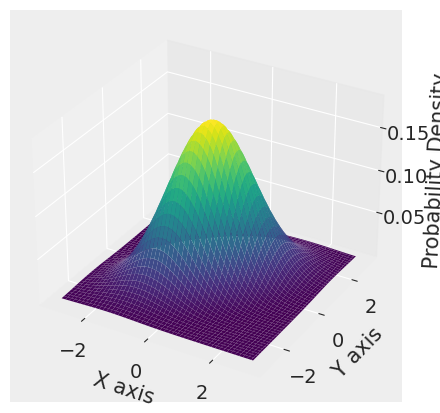

In [8]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# Parameters for the bivariate normal distribution
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]  # Diagonal covariance

# Create grid and multivariate normal
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal(mean, cov)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
Z = rv.pdf(pos)
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Probability Density')
plt.show()

# Log-Normal Distribution

The Log-Normal distribution is a strictly-positive and long-tailed distribution, reflecting a random variable whose logarithm is normally distributed. This can be due to multiplicative processes, additivity in the logarithmic space, or a log-transformation of data for convenience. The logarithm of a Log-Normal distribution follows a Normal distribution, and the exponentiation of a normal distribution is Log-Normal. The product of independent Log-Normal distributions is also Log-Normal.

<u><i>PDF:</i></u>

$f(y;\mu, \sigma) = \frac{1}{y\sqrt{2\pi\sigma^2}}\,\mathrm{e}^{-(\ln y-\mu)^2/2\sigma^2}$

<u><i>Expected Value:</i></u> $\displaystyle{\mathrm{e}^{\mu + \sigma^2/2}}, \nu \gt 1$

<u><i>Variance:</i></u> $\left(\mathrm{e}^{\sigma^2} - 1\right)\mathrm{e}^{2\mu + \sigma^2}$

<u><i>CDF:</i></u>

$F(y;\mu, \sigma) =\frac{1}{2}\left(1 + \text{erf}\left(\frac{\ln y - \mu}{\sigma\sqrt{2}}\right)\right),$

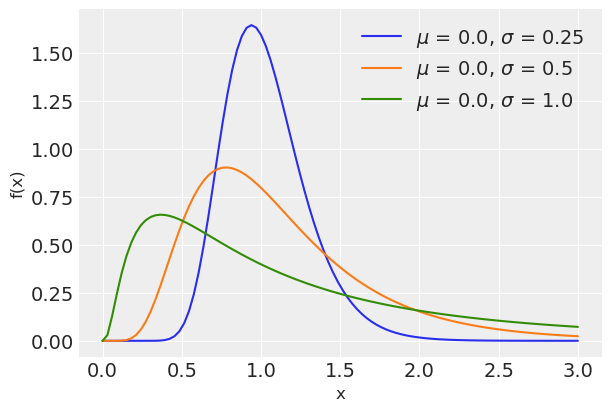

In [9]:
x = np.linspace(0, 3, 100)
mus = [0., 0., 0.]
sigmas = [.25, .5, 1.]
for mu, sigma in zip(mus, sigmas):
    pdf = st.lognorm.pdf(x, sigma, scale=np.exp(mu))
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}'.format(mu, sigma))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Student's T-Distribution

The t-distribution arises when sampling from data that are approximately Gaussian. Compared to the standard Normal distribution, it shows longer tails and taller shoulders. The standard t-distribution is parameterized only in terms of degrees of freedom $\nu$, however, a parameterization more commonly found in software allows for parametrization which adds location and scale. 

<u><i>PDF, Standard t-Distribution:</i></u>

$f(y; \nu) = \frac { \Gamma \left( \frac{v+1}{2} \right) } { \sqrt{\nu \pi} \Gamma \left( \frac{\nu}{2} \right) } \left( 1 + \frac{t^2}{\nu} \right)^{\frac{-\nu + 1}{2}}$

<u><i>Expected Value:</i></u> $0$

<u><i>Variance:</i></u> $\frac{\nu}{\nu-2}, \nu \gt 2$


<u><i>PDF, Non-Central t-Distribution:</i></u>

$f(y;\nu, \mu, \sigma) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right)\sqrt{\pi \nu \sigma^2}}\left(1 + \frac{(y-\mu)^2}{\nu \sigma^2}\right)^{-\frac{\nu + 1}{2}}$

<u><i>Expected Value:</i></u> $\mu, \nu \gt 1$

<u><i>Variance:</i></u>: $\displaystyle{\frac{\nu}{\nu - 2}}\,\sigma^2, \nu \gt 2$

<u><i>CDF:</i></u>

$F(y;\nu, \mu, \sigma) = \left\{\begin{array}{lll}
\displaystyle{1 - \frac{1}{2}I_{\nu/x^2 + \nu}\left(\frac{\nu}{2}, \frac{1}{2}\right)} & & \text{for }\displaystyle{x = \frac{y-\mu}{\sigma} \le 0},\\[0.5em]
\displaystyle{\frac{1}{2}I_{\nu/x^2 + \nu}\left(\frac{\nu}{2}, \frac{1}{2}\right)} & & \text{for }\displaystyle{x = \frac{y-\mu}{\sigma} > 0},
\end{array}
\right.$

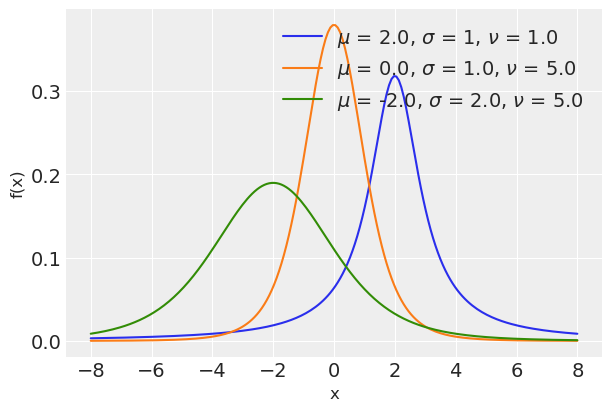

In [10]:
x = np.linspace(-8, 8, 200)
mus = [2., 0., -2.]
sigmas = [1, 1., 2.]
dfs = [1., 5., 5.]
for mu, sigma, df in zip(mus, sigmas, dfs):
    pdf = st.t.pdf(x, df, loc=mu, scale=sigma)
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}, $\nu$ = {}'.format(mu, sigma, df))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Half Student-T

Like the Half-Normal, the Half Student-T distribution is truncated to only outcomes greater than the location of the peak.

<u><i>PDF:</i></u>

$f(y;\nu, \mu, \sigma) =
\frac{2\Gamma\left(\frac{\nu+1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right)\sqrt{\pi \nu \sigma^2}}\left(1 + \frac{(y-\mu)^2}{\nu \sigma^2}\right)^{-\frac{\nu + 1}{2}}.$

<u><i>Expected Value:</i></u> $\mu + 2\sigma\sqrt{\frac{\nu}{\pi}}\,\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right)(\nu-1)}$

<u><i>Variance:</i></u> $\sigma^2\left(\frac{\nu}{\nu - 2}-\frac{4\nu}{\pi(\nu-1)^2}\left(\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right)}\right)^2\right)$

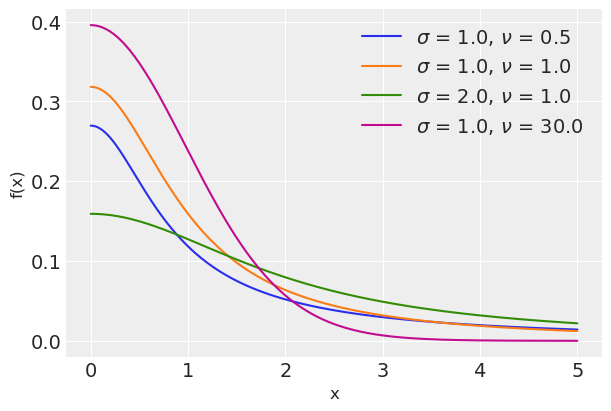

In [11]:
x = np.linspace(0, 5, 200)
sigmas = [1., 1., 2., 1.]
nus = [.5, 1., 1., 30.]
for sigma, nu in zip(sigmas, nus):
    pdf = st.t.pdf(x, df=nu, loc=0, scale=sigma)
    plt.plot(x, pdf, label=r'$\sigma$ = {}, $\nu$ = {}'.format(sigma, nu))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Cauchy

The Cauchy distribution is a t-distribution with one degree of freedom. This has some special properties. It has a peak at $\mu$, but the first and second moments (mean and variance) are undefined due to an integral that does not decay rapidly enough to produce a finite result. So the mean is undefined, and the variance is infinite.

<u><i>PDF:</i></u>

$f(y;\mu,\sigma) = \frac{1}{\pi \sigma}\,\frac{1}{1 + (y-\mu)^2/\sigma^2}.$

<u><i>CDF:</i></u>

$F(y;\mu,\sigma) = \frac{1}{2} + \frac{1}{\pi}\,\arctan\left(\frac{y - \mu}{\sigma}\right).$

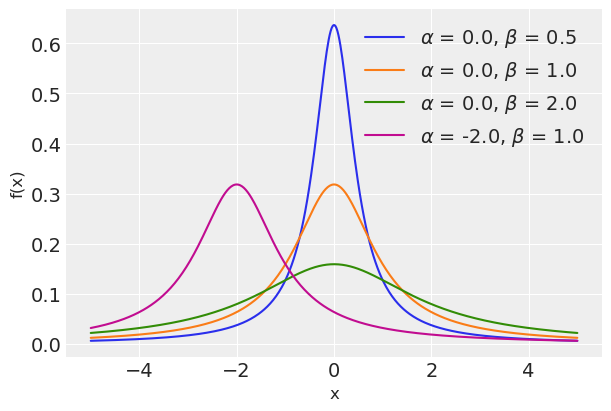

In [12]:
x = np.linspace(-5, 5, 500)
alphas = [0., 0., 0., -2.]
betas = [.5, 1., 2., 1.]
for a, b in zip(alphas, betas):
    pdf = st.cauchy.pdf(x, loc=a, scale=b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Half-Cauchy

Analogous to the Half-Normal and Half Student-T, one can truncate the Cauchy to only values above the peak.

<u><i>PDF:</i></u>

$f(y;\mu, \sigma) = \frac{2}{\pi \sigma}\,\frac{1}{1 + (y-\mu)^2/\sigma^2}$

<u><i>CDF:</i></u>

$F(y;\mu, \sigma) = \left\{\begin{array}{cll}
\displaystyle{\frac{2}{\pi}\,\arctan\left(\frac{y-\mu}{\sigma}\right)} &  & y \ge \mu \\[1em]
0 & & \text{otherwise}.
\end{array}\right.$

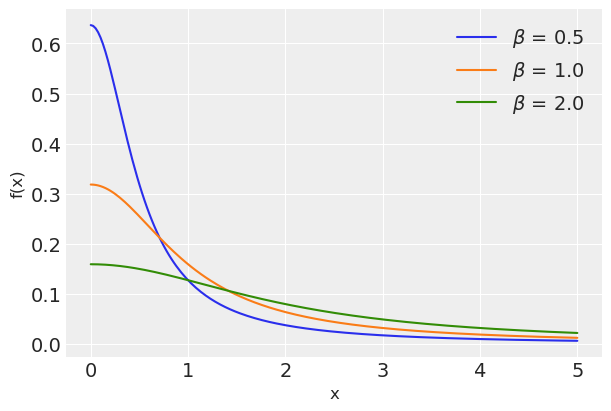

In [13]:
x = np.linspace(0, 5, 200)
for b in [0.5, 1.0, 2.0]:
    pdf = st.cauchy.pdf(x, scale=b)
    plt.plot(x, pdf, label=r'$\beta$ = {}'.format(b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

The next article in the series is about another family of continuous distributions, and can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Continuous%20Distributions%20II.ipynb">here</a>.

# References

- Blitzstein, J. (2019). Introduction to Probability (2nd ed.). Harvard University and Stanford University. https://drive.google.com/file/d/1VmkAAGOYCTORq1wxSQqy255qLJjTNvBI/view</br>

- (n.d.). Distribution Explorer. https://distribution-explorer.github.io/index.html

- (n.d.). PyMC API. Distributions. https://www.pymc.io/projects/docs/en/stable/api/distributions.html